# IMDB Sentiment Analysis — Exploratory Data Analysis

**Dataset:** [IMDB 50K Movie Reviews](https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews)

## 1. Install & Imports

In [1]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from bs4 import BeautifulSoup
from sklearn.feature_extraction.text import CountVectorizer

# ── Plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f1117',
    'axes.facecolor'   : '#0f1117',
    'axes.edgecolor'   : '#2e3140',
    'axes.labelcolor'  : '#c9d1d9',
    'axes.titlecolor'  : '#ffffff',
    'axes.grid'        : True,
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.6,
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'font.family'      : 'monospace',
    'figure.dpi'       : 120,
})

POS_COLOR = '#3fb950'   # green  → positive
NEG_COLOR = '#f85149'   # red    → negative
ACC_COLOR = '#58a6ff'   # blue   → accent / neutral
PALETTE   = [POS_COLOR, NEG_COLOR]

## 2. Load Data

In [2]:
import kagglehub

path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')
print('Dataset path:', path)

Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
Dataset path: /kaggle/input/imdb-dataset-of-50k-movie-reviews


In [3]:
df = pd.read_csv(os.path.join(path, 'IMDB Dataset.csv'))
print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## 3. Basic Overview

In [4]:
print('=== dtypes ===')
print(df.dtypes)
print()
print('=== describe ===')
df.describe(include='all')

=== dtypes ===
review       object
sentiment    object
dtype: object

=== describe ===


,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [5]:
# ── Missing values ──────────────────────────────────────────────────────
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)

# ── Duplicates ──────────────────────────────────────────────────────────
n_dup = df.duplicated(subset=['review']).sum()
print(f'\nDuplicate reviews : {n_dup}')

if n_dup > 0:
    df.drop_duplicates(subset=['review'], inplace=True)
    df.reset_index(drop=True, inplace=True)
    print(f'Rows after dedup  : {len(df)}')

Missing values per column:
review       0
sentiment    0
dtype: int64

Duplicate reviews : 418
Rows after dedup  : 49582


## 4. Class Distribution

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

Balance ratio: 99.25%


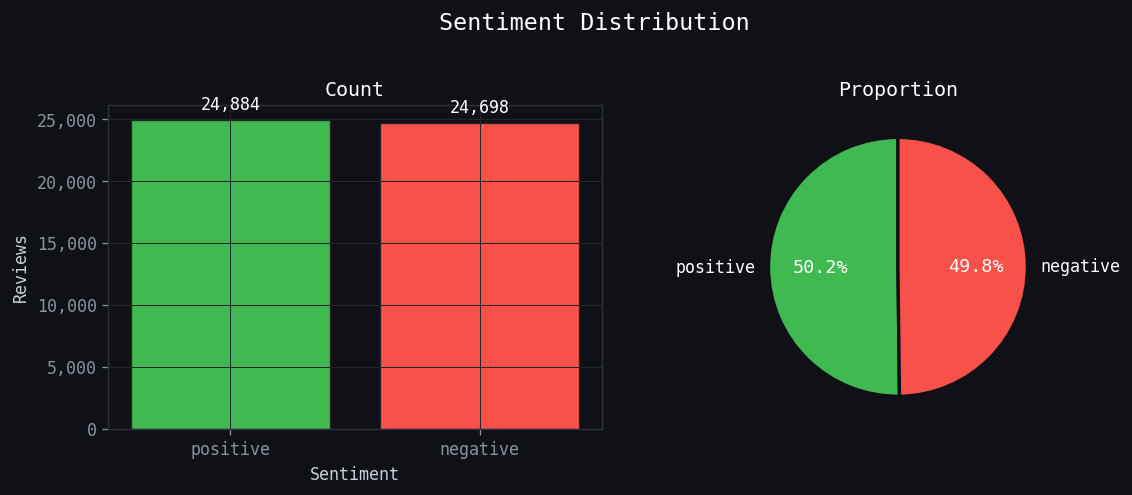

In [6]:
counts = df['sentiment'].value_counts()
print(counts)
print(f'\nBalance ratio: {counts.min()/counts.max():.2%}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Sentiment Distribution', fontsize=14, color='white', y=1.02)

# Bar chart
bars = axes[0].bar(counts.index, counts.values,
                   color=[POS_COLOR, NEG_COLOR], edgecolor='#21262d', linewidth=0.8)
axes[0].bar_label(bars, fmt='{:,.0f}', padding=4, color='white', fontsize=10)
axes[0].set_title('Count')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Reviews')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    colors=[POS_COLOR, NEG_COLOR],
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2),
    textprops=dict(color='white')
)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

## 5. Text Length Analysis

In [7]:
# Helper: strip HTML before computing length
def clean_for_length(text):
    text = BeautifulSoup(text, 'html.parser').get_text()
    text = re.sub(r'http\S+|www\S+', '', text)
    return text

df['clean_text']   = df['review'].apply(clean_for_length)
df['word_count']   = df['clean_text'].apply(lambda x: len(x.split()))
df['char_count']   = df['clean_text'].apply(len)
df['sent_count']   = df['clean_text'].apply(lambda x: len(re.findall(r'[.!?]+', x)) + 1)
df['avg_word_len'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if x.split() else 0
)

print(df[['word_count', 'char_count', 'sent_count', 'avg_word_len']]
      .describe().round(2))

       word_count  char_count  sent_count  avg_word_len
count    49582.00    49582.00    49582.00      49582.00
mean       227.30     1286.16       14.14          4.64
std        168.47      972.13        9.37          0.34
min          4.00       32.00        1.00          1.24
25%        125.00      689.00        8.00          4.41
50%        171.00      954.00       12.00          4.62
75%        276.00     1560.00       17.00          4.84
max       2450.00    13584.00      283.00         13.53


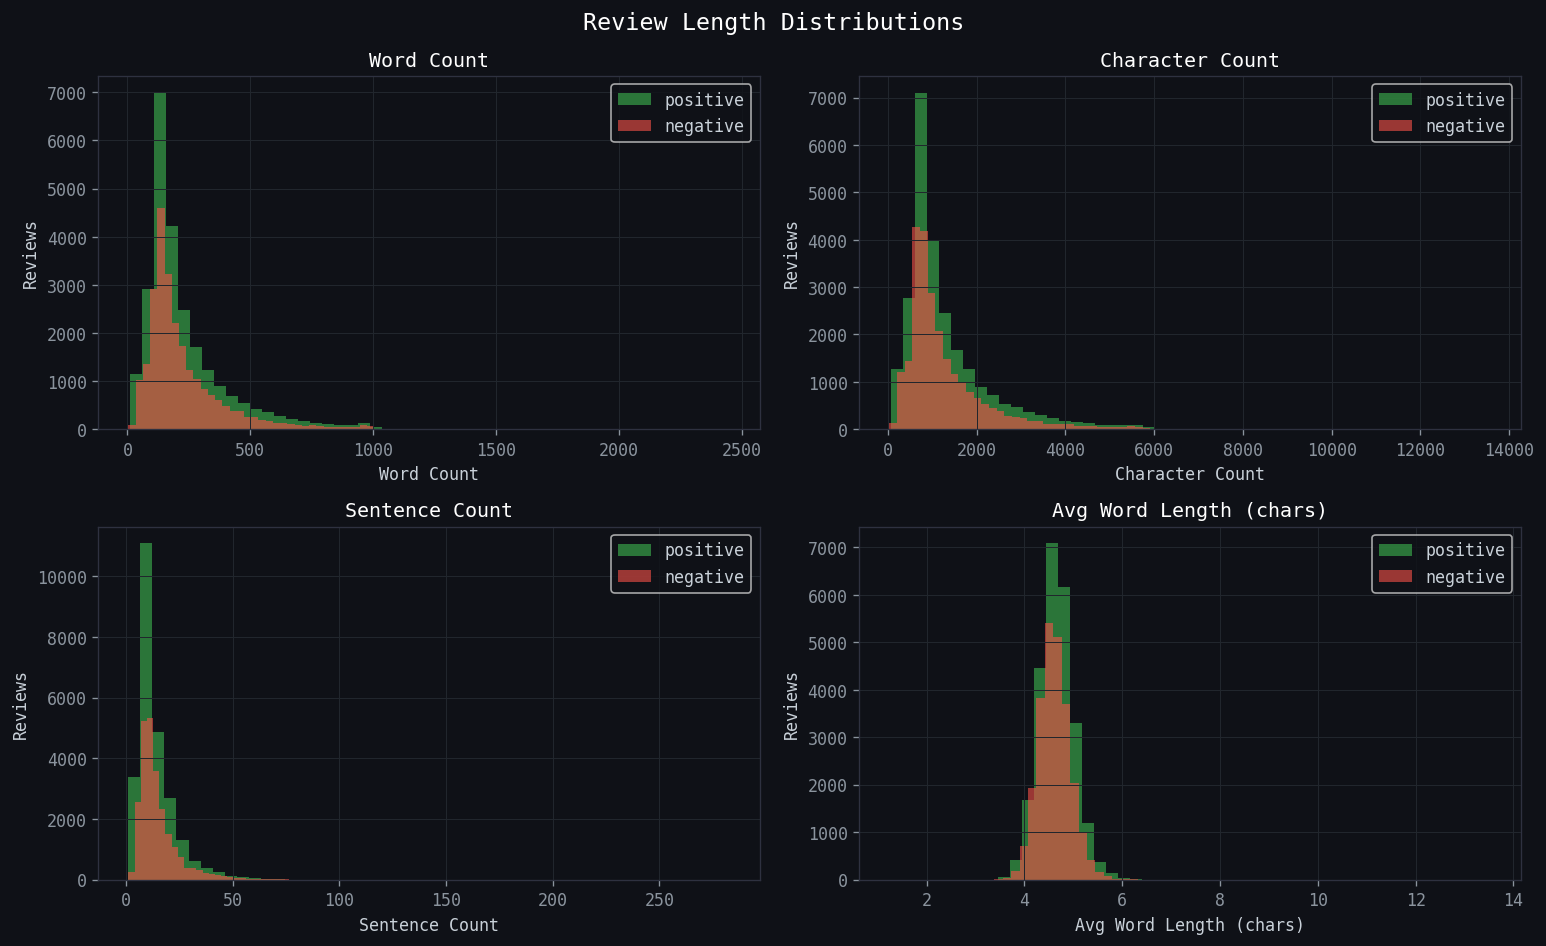

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Review Length Distributions', fontsize=14, color='white')

metrics = [
    ('word_count',   'Word Count',              200),
    ('char_count',   'Character Count',          50),
    ('sent_count',   'Sentence Count',           2),
    ('avg_word_len', 'Avg Word Length (chars)',  0.2),
]

for ax, (col, title, bw) in zip(axes.flat, metrics):
    for sentiment, color in zip(['positive', 'negative'], PALETTE):
        subset = df[df['sentiment'] == sentiment][col]
        ax.hist(subset, bins=50, alpha=0.6, color=color,
                label=sentiment, edgecolor='none')
    ax.set_title(title)
    ax.set_xlabel(title)
    ax.set_ylabel('Reviews')
    ax.legend()

plt.tight_layout()
plt.show()

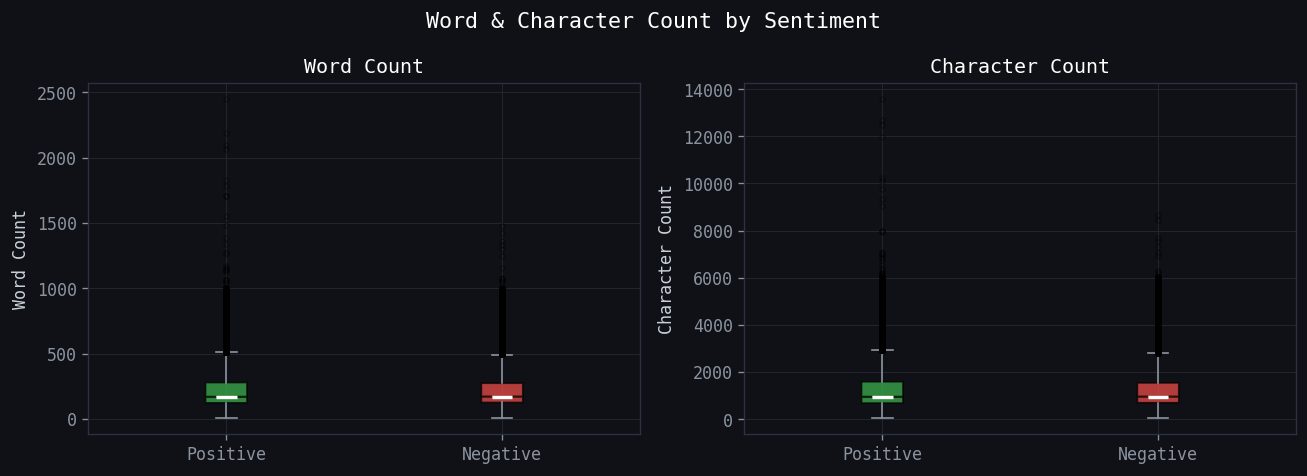

Mean word count by sentiment:
            mean  median    std
sentiment                      
negative   225.4   171.0  162.0
positive   229.2   170.0  174.6


In [9]:
# Boxplots — sentiment vs word count / char count
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Word & Character Count by Sentiment', fontsize=13, color='white')

for ax, col, label in zip(axes,
                           ['word_count', 'char_count'],
                           ['Word Count', 'Character Count']):
    data = [df[df['sentiment'] == s][col] for s in ['positive', 'negative']]
    bp = ax.boxplot(data, patch_artist=True, notch=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color='#8b949e'),
                    capprops=dict(color='#8b949e'),
                    flierprops=dict(marker='.', color='#8b949e', alpha=0.3))
    for patch, color in zip(bp['boxes'], PALETTE):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Positive', 'Negative'])
    ax.set_ylabel(label)
    ax.set_title(label)

plt.tight_layout()
plt.show()

print('Mean word count by sentiment:')
print(df.groupby('sentiment')['word_count'].agg(['mean','median','std']).round(1))

In [10]:
# Percentile table
pcts = [50, 75, 90, 95, 99]
pct_df = pd.DataFrame({
    'All'      : np.percentile(df['word_count'], pcts),
    'Positive' : np.percentile(df[df['sentiment']=='positive']['word_count'], pcts),
    'Negative' : np.percentile(df[df['sentiment']=='negative']['word_count'], pcts),
}, index=[f'{p}th' for p in pcts])
print('Word Count Percentiles:')
print(pct_df.astype(int))

Word Count Percentiles:
      All  Positive  Negative
50th  171       170       171
75th  276       278       273
90th  444       458       430
95th  581       597       562
99th  893       907       870


## 6. Most Common Words

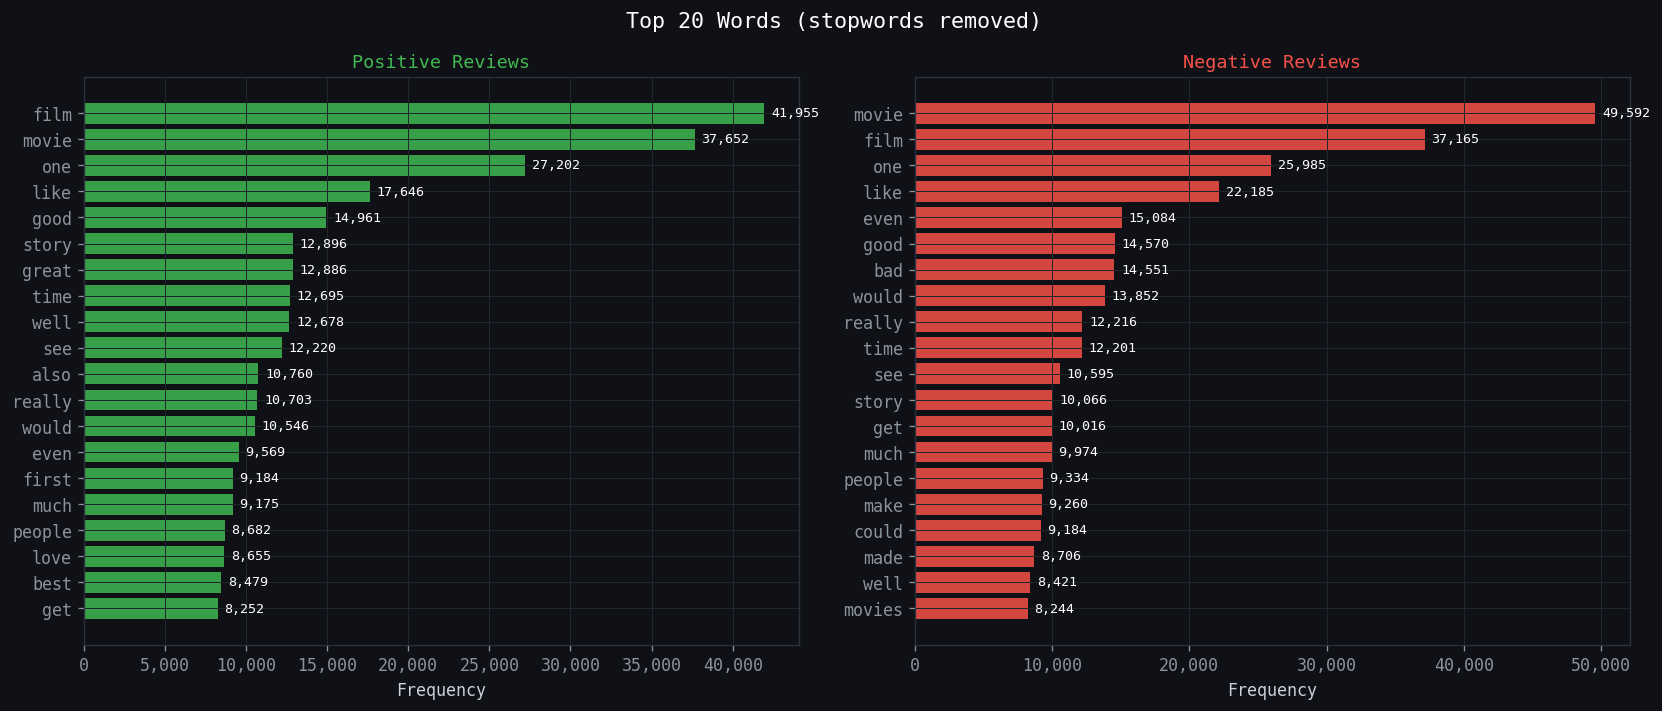

In [11]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)

STOP = set(stopwords.words('english'))

def get_top_words(texts, n=20, min_len=3):
    words = []
    for text in texts:
        text = BeautifulSoup(text, 'html.parser').get_text().lower()
        text = re.sub(r'[^a-z\s]', ' ', text)
        words.extend([
            w for w in text.split()
            if w not in STOP and len(w) >= min_len
        ])
    return Counter(words).most_common(n)

top_pos = get_top_words(df[df['sentiment']=='positive']['review'])
top_neg = get_top_words(df[df['sentiment']=='negative']['review'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Top 20 Words (stopwords removed)', fontsize=13, color='white')

for ax, top, color, title in zip(
        axes,
        [top_pos, top_neg],
        [POS_COLOR, NEG_COLOR],
        ['Positive Reviews', 'Negative Reviews']
):
    words, freqs = zip(*top)
    bars = ax.barh(list(reversed(words)), list(reversed(freqs)),
                   color=color, edgecolor='none', alpha=0.85)
    ax.bar_label(bars, fmt='{:,.0f}', padding=4, color='white', fontsize=8)
    ax.set_title(title, color=color, fontsize=11)
    ax.set_xlabel('Frequency')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

plt.tight_layout()
plt.show()

## 7. Word Clouds

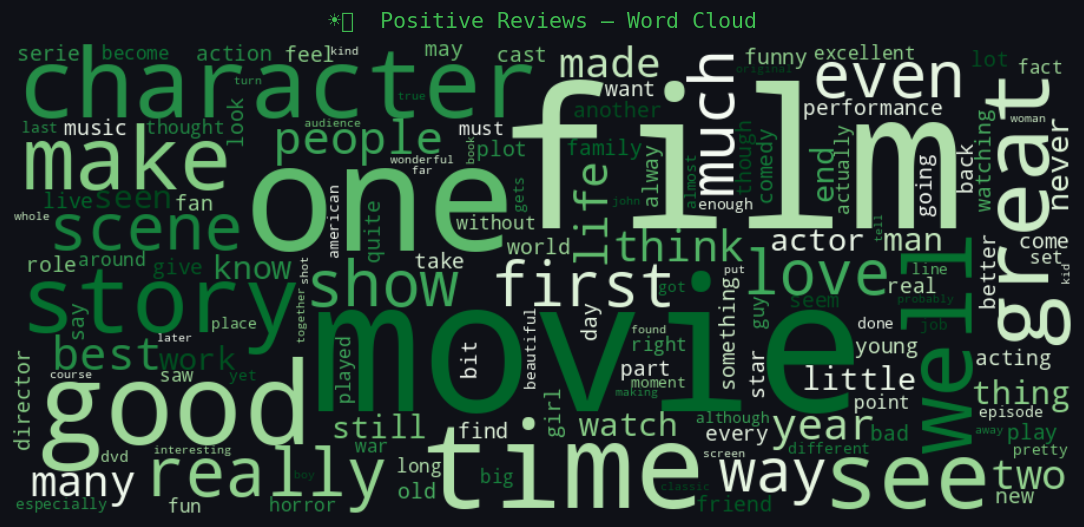

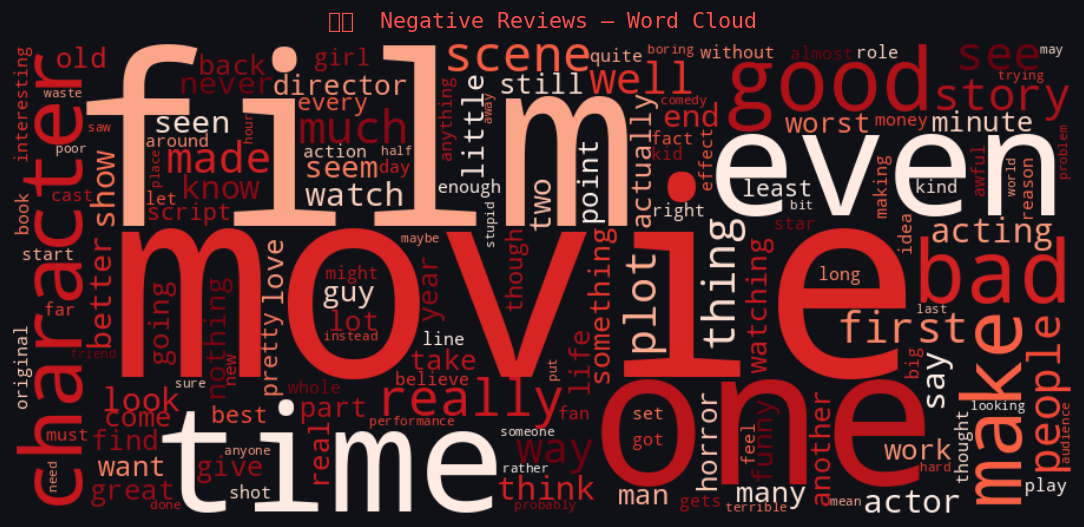

In [12]:
def make_wordcloud(texts, color, title):
    corpus = ' '.join(texts)
    corpus = BeautifulSoup(corpus, 'html.parser').get_text()
    corpus = re.sub(r'[^a-zA-Z\s]', ' ', corpus).lower()
    corpus = ' '.join(w for w in corpus.split() if w not in STOP and len(w) >= 3)

    wc = WordCloud(
        width=900, height=400,
        background_color='#0f1117',
        colormap='Greens' if color == POS_COLOR else 'Reds',
        max_words=150,
        collocations=False,
        prefer_horizontal=0.8
    ).generate(corpus)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(title, fontsize=13, color=color, pad=10)
    plt.tight_layout()
    plt.show()

make_wordcloud(
    df[df['sentiment']=='positive']['review'],
    POS_COLOR, '☀️  Positive Reviews — Word Cloud'
)
make_wordcloud(
    df[df['sentiment']=='negative']['review'],
    NEG_COLOR, '🌧️  Negative Reviews — Word Cloud'
)

## 8. N-gram Analysis (Bigrams & Trigrams)

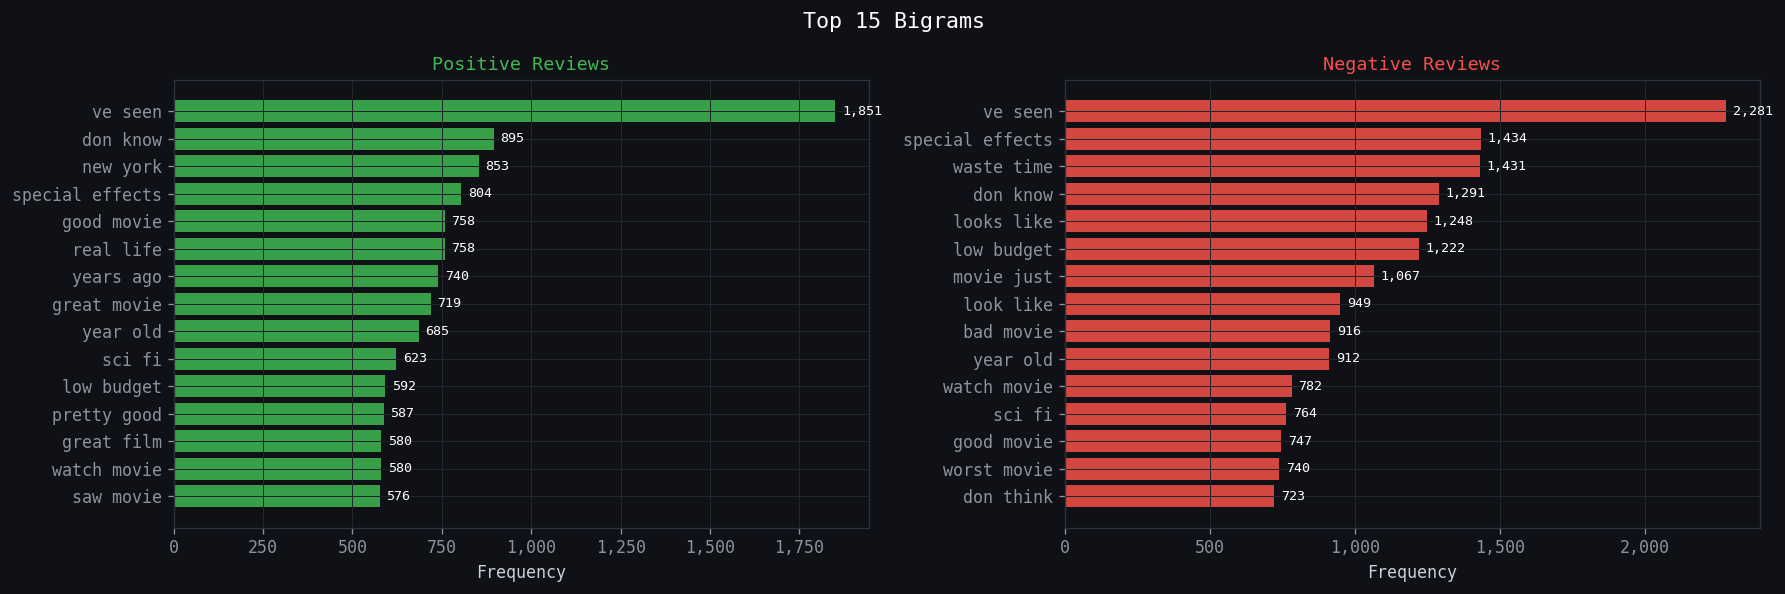

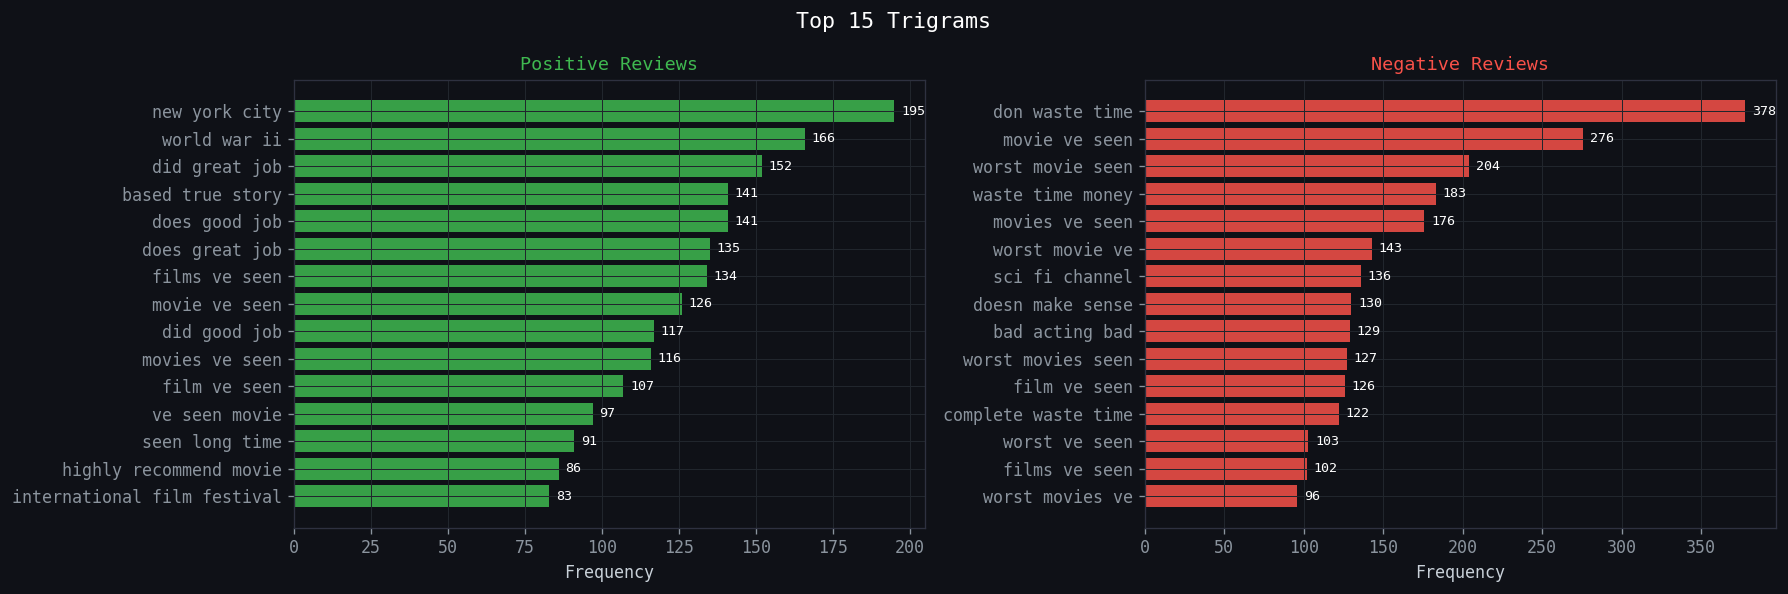

In [13]:
def get_top_ngrams(texts, n=2, top_k=15):
    corpus = []
    for text in texts:
        text = BeautifulSoup(text, 'html.parser').get_text().lower()
        text = re.sub(r'[^a-z\s]', ' ', text)
        corpus.append(text)

    vec = CountVectorizer(
        ngram_range=(n, n),
        stop_words='english',
        max_features=10_000,
        min_df=5
    )
    X = vec.fit_transform(corpus)
    freqs = X.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    top = sorted(zip(vocab, freqs), key=lambda x: -x[1])[:top_k]
    return top


def plot_ngrams(pos_ngrams, neg_ngrams, title):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=13, color='white')

    for ax, ngrams, color, label in zip(
            axes, [pos_ngrams, neg_ngrams],
            [POS_COLOR, NEG_COLOR],
            ['Positive', 'Negative']
    ):
        phrases, freqs = zip(*ngrams)
        bars = ax.barh(list(reversed(phrases)), list(reversed(freqs)),
                       color=color, alpha=0.85, edgecolor='none')
        ax.bar_label(bars, fmt='{:,.0f}', padding=4, color='white', fontsize=8)
        ax.set_title(f'{label} Reviews', color=color, fontsize=11)
        ax.set_xlabel('Frequency')
        ax.xaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

    plt.tight_layout()
    plt.show()


# ── Bigrams ──────────────────────────────────────────────────────────────
bi_pos = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=2)
bi_neg = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=2)
plot_ngrams(bi_pos, bi_neg, 'Top 15 Bigrams')

# ── Trigrams ─────────────────────────────────────────────────────────────
tri_pos = get_top_ngrams(df[df['sentiment']=='positive']['review'], n=3)
tri_neg = get_top_ngrams(df[df['sentiment']=='negative']['review'], n=3)
plot_ngrams(tri_pos, tri_neg, 'Top 15 Trigrams')

## 9. Vocabulary — Unique vs Shared Words

Positive vocabulary  : 74,468 words
Negative vocabulary  : 71,829 words
Shared               : 45,558 words
Exclusive to positive: 28,910 words
Exclusive to negative: 26,271 words


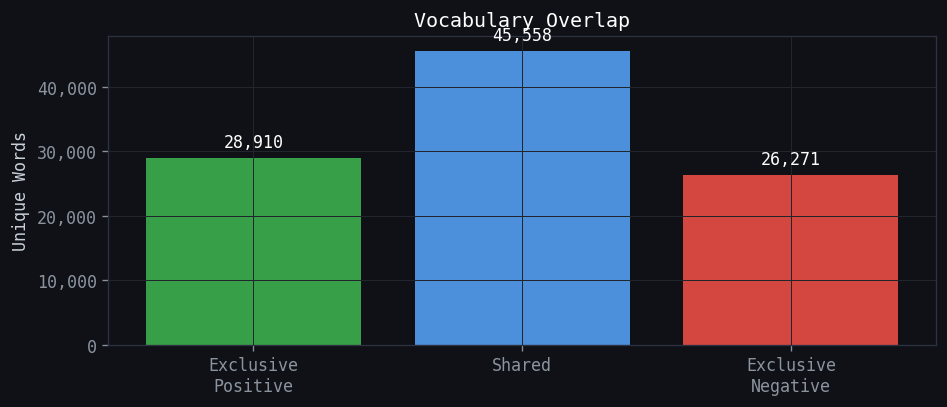

In [14]:
def vocab_set(texts, min_len=3):
    words = set()
    for text in texts:
        text = BeautifulSoup(text, 'html.parser').get_text().lower()
        text = re.sub(r'[^a-z\s]', ' ', text)
        words.update(
            w for w in text.split()
            if w not in STOP and len(w) >= min_len
        )
    return words

vocab_pos = vocab_set(df[df['sentiment']=='positive']['review'])
vocab_neg = vocab_set(df[df['sentiment']=='negative']['review'])

shared    = vocab_pos & vocab_neg
only_pos  = vocab_pos - vocab_neg
only_neg  = vocab_neg - vocab_pos

print(f'Positive vocabulary  : {len(vocab_pos):,} words')
print(f'Negative vocabulary  : {len(vocab_neg):,} words')
print(f'Shared               : {len(shared):,} words')
print(f'Exclusive to positive: {len(only_pos):,} words')
print(f'Exclusive to negative: {len(only_neg):,} words')

# ── Venn-style bar ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
labels = ['Exclusive\nPositive', 'Shared', 'Exclusive\nNegative']
values = [len(only_pos), len(shared), len(only_neg)]
colors = [POS_COLOR, ACC_COLOR, NEG_COLOR]
bars = ax.bar(labels, values, color=colors, edgecolor='none', alpha=0.85)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, color='white')
ax.set_title('Vocabulary Overlap', color='white')
ax.set_ylabel('Unique Words')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout()
plt.show()

## 10. Review Length Heatmap

sentiment      negative  positive  positive_pct
length_bucket                                  
<100               2964      3488     54.060756
100-200           11876     11459     49.106492
200-300            4661      4477     48.993215
300-500            3500      3440     49.567723
500-700            1062      1276     54.576561
700-1000            622       715     53.477936
1000+                13        29     69.047619


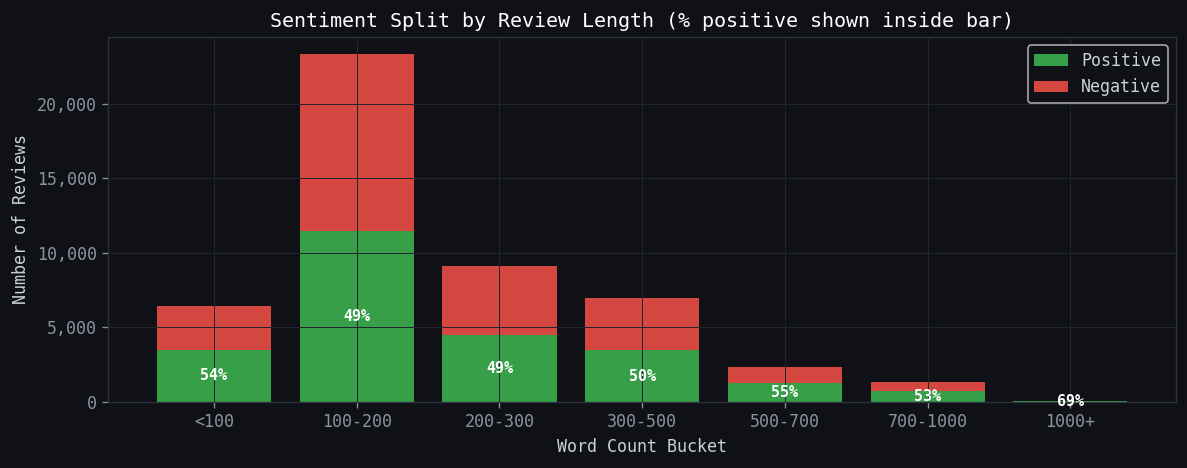

In [15]:
# Bucket reviews by length and see sentiment split
bins   = [0, 100, 200, 300, 500, 700, 1000, np.inf]
labels = ['<100', '100-200', '200-300', '300-500', '500-700', '700-1000', '1000+']

df['length_bucket'] = pd.cut(df['word_count'], bins=bins, labels=labels)

heat = (
    df.groupby(['length_bucket', 'sentiment'])
      .size()
      .unstack(fill_value=0)
)
heat['positive_pct'] = heat['positive'] / (heat['positive'] + heat['negative']) * 100

print(heat)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(heat.index.astype(str), heat['positive'],
       label='Positive', color=POS_COLOR, alpha=0.85)
ax.bar(heat.index.astype(str), heat['negative'],
       bottom=heat['positive'], label='Negative', color=NEG_COLOR, alpha=0.85)

for i, (pos_pct) in enumerate(heat['positive_pct']):
    ax.text(i, heat['positive'].iloc[i] / 2,
            f'{pos_pct:.0f}%', ha='center', va='center',
            color='white', fontsize=9, fontweight='bold')

ax.set_title('Sentiment Split by Review Length (% positive shown inside bar)')
ax.set_xlabel('Word Count Bucket')
ax.set_ylabel('Number of Reviews')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
plt.show()

## 11. EDA Summary

In [16]:
print('=' * 55)
print('            EDA SUMMARY — IMDB Dataset')
print('=' * 55)
print(f'Total reviews        : {len(df):,}')
print(f'Positive             : {(df["sentiment"]=="positive").sum():,}')
print(f'Negative             : {(df["sentiment"]=="negative").sum():,}')
print(f'Class balance        : {(df["sentiment"]=="positive").mean():.1%} pos')
print()
print(f'Avg word count       : {df["word_count"].mean():.0f} words')
print(f'Median word count    : {df["word_count"].median():.0f} words')
print(f'95th pct word count  : {df["word_count"].quantile(.95):.0f} words')
print(f'Max word count       : {df["word_count"].max()} words')
print()
print(f'Total vocabulary     : {len(vocab_pos | vocab_neg):,} unique words')
print(f'Shared words         : {len(shared):,}')
print(f'Positive-only words  : {len(only_pos):,}')
print(f'Negative-only words  : {len(only_neg):,}')
print('=' * 55)

            EDA SUMMARY — IMDB Dataset
Total reviews        : 49,582
Positive             : 24,884
Negative             : 24,698
Class balance        : 50.2% pos

Avg word count       : 227 words
Median word count    : 171 words
95th pct word count  : 581 words
Max word count       : 2450 words

Total vocabulary     : 100,739 unique words
Shared words         : 45,558
Positive-only words  : 28,910
Negative-only words  : 26,271
